In [44]:
%cd /depot/bingxin/data/env/data_test

/depot/bingxin/data/env/data_test


In [45]:
!pwd

/depot/bingxin/data/env/data_test


In [46]:
import numpy as np
import csv, os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
import mpmath as mp
from mpmath import mpf, exp, findroot, almosteq
from collections import Counter
warnings.filterwarnings("ignore", category=RuntimeWarning)
import time
import sys
from fractions import Fraction

!apt-get install -y texlive texlive-latex-extra texlive-fonts-recommended dvipng cm-super

# Set the text properties to use LaTeX fonts
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 33  # 30 for two pictures in a row
plt.rcParams['figure.figsize'] = (8, 8)  # width, height in inches
plt.rcParams['figure.dpi'] = 300  # dots per inch
plt.rcParams['font.family'] = 'serif'  # Use serif fonts to match LaTeX's default

def format_func(value, tick_number):
    if value < 10:
        return f"{value:.2f}"
    elif value < 100:
        return f"{value:.1f}"
    else:
        return f"{int(value)}"

start_time = time.time()

############# Precision #############
accuracy = 50
mp.dps = accuracy

mp.mp.dps = 50  # Set 50 decimal places of precision

/bin/bash: apt-get: command not found


In [47]:
## Test Machine Error

s = 1.0

for k in range(1, 101):
    s /= 2.0
    if (1.0 + s) <= 1.0:
        s *= 2.0
        print('Machine Epsilon by default (not privacy budget):', f"k={k-1}, eps={s}")
        break

s = mp.mpf('1.0')

for k in range(1, 1001):
    s /= mp.mpf('2.0')
    if (mp.mpf('1.0') + s) <= mp.mpf('1.0'):
        s *= mp.mpf('2.0')
        print('Machine Epsilon by mpmath (not privacy budget):', f"k={k-1}, eps={s}")
        break

Machine Epsilon by default (not privacy budget): k=52, eps=2.220446049250313e-16
Machine Epsilon by mpmath (not privacy budget): k=168, eps=2.672764710092195646140536467151481878815196880105e-51


In [48]:
## one record may change from path_num_1 to path_num_2 due to the choice of sensitivity
path_num_1 = 13
path_num_2 = 13

In [49]:
## Preparation

### Parameters
zero = mp.mpf('0')
one = mp.mpf('1')
two = mp.mpf('2')
three = mp.mpf('3')
four = mp.mpf('4')
five = mp.mpf('5')
six = mp.mpf('6')
seven = mp.mpf('7')
eight = mp.mpf('8')
nine = mp.mpf('9')

ten = mp.mpf('10')
eleven = mp.mpf('11')
twelve = mp.mpf('12')
thirteen = mp.mpf('13')
fourteen = mp.mpf('14')
fifteen = mp.mpf('15')
sixteen = mp.mpf('16')
seventeen = mp.mpf('17')
eighteen = mp.mpf('18')
nineteen = mp.mpf('19')

twenty = mp.mpf('20')
twenty_one = mp.mpf('21')
twenty_two = mp.mpf('22')
twenty_three = mp.mpf('23')
twenty_four = mp.mpf('24')
twenty_five = mp.mpf('25')
twenty_six = mp.mpf('26')
twenty_seven = mp.mpf('27')
twenty_eight = mp.mpf('28')
twenty_nine = mp.mpf('29')

thirty_two = mp.mpf('32')
forty_five = mp.mpf('45')
sixty_four = mp.mpf('64')
two_over_45 = two / forty_five


ten = mp.mpf('10')
hundred = mp.mpf('100')
one_fifty = mp.mpf('150')
thousand = mp.mpf('1000')

def float_to_mpf(x):
    return mp.mpf(x)

def fraction_to_mpf(frac):
    """Convert a Fraction to an mpmath.mpf with high precision."""
    num = mp.mpf(frac.numerator)
    denom = mp.mpf(frac.denominator)
    return num / denom

In [50]:
### read allocation path
file_path_1 = f"allocation_path/dhc_allocation_path_{path_num_1}.csv"
df_1 = pd.read_csv(file_path_1)

allocation_run_1 = []
for col in df_1.columns:
    allocation_run_1.extend(df_1[col].tolist())

file_path_2 = f"allocation_path/dhc_allocation_path_{path_num_2}.csv"
df_2 = pd.read_csv(file_path_2)

allocation_run_2 = []
for col in df_2.columns:
    allocation_run_2.extend(df_2[col].tolist())

allocation_run = [entry for entry in allocation_run_1 if entry != '0/1'] + \
                 [entry for entry in allocation_run_2 if entry != '0/1']

allocation_run[:22], len(allocation_run)

from fractions import Fraction

allocation_run_sorted = sorted(
    allocation_run,
    key=lambda x: Fraction(x.strip("'"))
)

allocation_run = allocation_run_sorted
allocation_run[:22], len(allocation_run)


rho_1 = [Fraction(s) for s in allocation_run_1]
rho_2 = [Fraction(s) for s in allocation_run_2]
if rho_1 != rho_2:
    print("Incorrect Allocations")

In [51]:
## Determine Parameters

### Delta

Delta = mp.mpf('1e-36')

### rho

rho_path = [Fraction(s) for s in allocation_run]
rho = sum(rho_path)/2

### sigma2_list

sigma2_list = [1/val for val in rho_path]

### psi2

psi2 = 1/rho

### a_list

a_list = [val / rho for val in rho_path]

### L

# Extract the denominators of all percentage
denominators = [frac.denominator for frac in a_list]
numerators = [frac.numerator for frac in a_list]

# Compute LCM of all denominators using math.lcm
lcm_value = math.lcm(*denominators)
gcd_value = math.gcd(*numerators)

L = Fraction(lcm_value, gcd_value)

a_list_L = [val * L for val in a_list]
# print(a_list_L)

### m

m = len(a_list)

### convert to numerical

rho = fraction_to_mpf(rho)
a_list = [fraction_to_mpf(frac) for frac in a_list]
a_list_L = [fraction_to_mpf(frac) for frac in a_list_L]
m = float_to_mpf(m)
L = fraction_to_mpf(L)
psi2 = fraction_to_mpf(psi2)
sigma2_list = [fraction_to_mpf(frac) for frac in sigma2_list]

print("tolerance:", Delta, "rho", rho, "L:", L)

rho 4.9622 L: 49622.0


In [52]:
# Numerical Computation

### U

summ = mp.mpf('0')
for i in range(len(a_list)):
    summ += a_list[i]**2 * sigma2_list[i]

U = mp.ceil( L * mp.sqrt(- two * summ * mp.log(Delta / eight)) )

# optional only for nice expression of U, Find the smallest multiple of 100000 greater than U
step = mp.mpf('250000')
U = step * mp.ceil(U / step)

print(f"U must be larger than", U)

### N

summ = mp.mpf('0')
for i in range(len(a_list_L)):
    summ += a_list[i]**2 * sigma2_list[i]
log_term = mp.sqrt( - two  * summ * mp.log(Delta / eight) )

# ==== Final RHS expression ====
N = mp.ceil( U + L * log_term )

step = mp.mpf('250000')
N = step * mp.ceil(N / step)

print(f"N must be larger than", N)


U must be larger than 500000.0
N must be larger than 1000000.0


In [53]:
## Characteristic Functions

# Step 1: Get unique sigma2 values and their first occurrence indices
sigma2_index_map = {}
sigma2_unique_list = []
index_unique_list = []

for idx, sigma2 in enumerate(sigma2_list):
    if sigma2 not in sigma2_index_map:
        sigma2_index_map[sigma2] = len(sigma2_unique_list)
        sigma2_unique_list.append(sigma2)
        index_unique_list.append(idx)

# Step 2: Count appearances of each unique sigma2 value
appearance_counter = Counter(sigma2_list)
appearance_list = [appearance_counter[sigma2] for sigma2 in sigma2_unique_list]


print(appearance_counter)
print()
print(appearance_list)

Counter({mpf('20.920502092050209205020920502092050209205020920502099'): 36, mpf('909.09090909090909090909090909090909090909090909090971'): 20, mpf('23.255813953488372093023255813953488372093023255813955'): 20, mpf('136.98630136986301369863013698630136986301369863013682'): 18, mpf('10.01001001001001001001001001001001001001001001001002'): 18, mpf('32.258064516129032258064516129032258064516129032258059'): 16, mpf('11.520737327188940092165898617511520737327188940092176'): 16, mpf('8.0645161290322580645161290322580645161290322580645147'): 4, mpf('5.2301255230125523012552301255230125523012552301255247'): 4, mpf('2.880184331797235023041474654377880184331797235023044'): 4, mpf('34.246575342465753424657534246575342465753424657534204'): 2, mpf('2.5025025025025025025025025025025025025025025025025051'): 2})

[20, 18, 2, 16, 20, 36, 16, 18, 4, 4, 4, 2]


In [54]:
############# Characteristic Functions #############
def char_func_num(sigma_i2, a_i_L, zeta):
    # Precompute constants
    trunc = int(mp.ceil(twenty_four * two * sigma_i2) + one)

    denom_coeff = one / (two * sigma_i2)

    # Numerator sum
    numerator = one
    for x in range(1, trunc + 1):
        x_mpf = mp.mpf(x)
        numerator += two * mp.cos(a_i_L * zeta * x_mpf) * mp.exp(-x_mpf**2 * denom_coeff)

    return numerator


def char_func_num_prod(zeta):
    product = mp.mpf("1.0")
    for i in range(len(sigma2_unique_list)):
        sigma_i2 = sigma2_unique_list[i]
        a_i_L = a_list_L[index_unique_list[i]]
        char_val = char_func_num(sigma_i2, a_i_L, zeta)
        product *= char_val ** appearance_list[i]

    return product


char_func_denom_prod = char_func_num_prod(zero)


def char_func_values(zeta):
    values = []
    for i in range(len(sigma2_unique_list)):
        sigma_i2 = sigma2_unique_list[i]
        a_i_L = a_list_L[index_unique_list[i]]
        char_num_val = char_func_num(sigma_i2, a_i_L, zeta)
        char_denom_val = char_func_num(sigma_i2, a_i_L, zero)
        values.append( (char_num_val / char_denom_val) ** appearance_list[i] )

    return values


############# Weight Function #############
def weight_first(zeta, t_0, L):
    lower_1 = mp.ceil(t_0 * L)
    stable_cut = mp.mpf('1e-40')
    if abs(zeta) >= stable_cut:
        first = mp.cos(lower_1 * zeta) + mp.cos(U * zeta)
        factor = mp.cos(zeta / two) / mp.sin(zeta / two)
        second = mp.sin(U * zeta) - mp.sin(lower_1 * zeta)
        return (one / two) * (one / mp.pi) * (first + factor * second)

    elif 0 < abs(zeta) < stable_cut:
        first = mp.cos(lower_1 * zeta) + mp.cos(U * zeta)
        factor = mp.cos(zeta / two) / (zeta / two)
        second = mp.sin(U * zeta) - mp.sin(lower_1 * zeta)
        return (one / two) * (one / mp.pi) * (first + factor * second)

    else:
        return (one / mp.pi) * (U - lower_1 + one)

def weight_second(zeta, T_0, L):
    lower_2 = mp.ceil(T_0 * L)
    stable_cut = mp.mpf('1e-40')
    if abs(zeta) >= stable_cut:
        first = mp.cos(lower_2 * zeta) + mp.cos(U * zeta)
        factor = mp.cos(zeta / two) / mp.sin(zeta / two)
        second = mp.sin(U * zeta) - mp.sin(lower_2 * zeta)
        return (one / two) * (one / mp.pi) * (first + factor * second)

    elif 0 < abs(zeta) < stable_cut:
        first = mp.cos(lower_2 * zeta) + mp.cos(U * zeta)
        factor = mp.cos(zeta / two) / (zeta / two)
        second = mp.sin(U * zeta) - mp.sin(lower_2 * zeta)
        return (one / two) * (one / mp.pi) * (first + factor * second)

    else:
        return (one / mp.pi) * (U - lower_2 + one)

In [55]:
## Determine Threshold

results = []  # Initialize a list to store results

for i in range(len(sigma2_unique_list)):
    sigma_i2 = sigma2_unique_list[i]
    a_i_L = a_list_L[index_unique_list[i]]

    half_period = mp.pi / a_i_L
    zeta_list = np.linspace(0, 1, 10000) * half_period

    # Calculate char_denom_val once outside the loop for efficiency
    char_denom_val = char_func_num(sigma_i2, a_i_L, zero)

    for zeta in zeta_list:
        zeta_mpf = mp.mpf(zeta)

        char_num_val = char_func_num(sigma_i2, a_i_L, zeta_mpf)

        char_single = (char_num_val / char_denom_val) ** appearance_list[i]

        # Check stopping criterion
        if char_single < Delta/U:
            # Use formatted string for clearer output
            result_dict = {
                "sigma2": sigma_i2,
                "a_i_L": a_i_L,
                "zeta": zeta,
                "char_single": char_single
            }

            results.append(result_dict)

            # Print nicely formatted message
            print(f"Stopped at sigma2: {result_dict['sigma2']}, "
                  f"a_i_L: {result_dict['a_i_L']}, "
                  f"zeta: {result_dict['zeta']}, "
                  f"char_single: {result_dict['char_single']}")

            break  # break inner loop upon condition met

# Save the results to CSV for later analysis
df_results = pd.DataFrame(results)
df_results.to_csv(f'results_DHC_v0/eps_delta_curve/tmp/char_func_half_period_threshold_path_{path_num_1}_to_{path_num_2}.csv', index=False)


Stopped at sigma2: 909.09090909090909090909090909090909090909090909091, a_i_L: 11.0, zeta: 0.0093685949538358588640267467807839916782861043210736, char_single: 1.1746207808558728402617505520292284188060296071423e-42
Stopped at sigma2: 136.98630136986301369863013698630136986301369863014, a_i_L: 73.0, zeta: 0.0038262399788490170554751507510497573051950887695636, char_single: 1.6871413656545033138112449386076861450438636383794e-42
Stopped at sigma2: 34.246575342465753424657534246575342465753424657534, a_i_L: 292.0, zeta: 0.005735055986295067432184462551328179344003193308199, char_single: 1.9488545333998814697598601174978543207147002447456e-42
Stopped at sigma2: 32.258064516129032258064516129032258064516129032258, a_i_L: 310.0, zeta: 0.0019682526101872697985625668484153345796150378908094, char_single: 1.8830995866920678773734740276177667815805618017079e-42
Stopped at sigma2: 23.255813953488372093023255813953488372093023255814, a_i_L: 430.0, zeta: 0.00149496311706629201360403867547283763507

In [56]:
# Load previously computed data
df_results = pd.read_csv(f'results_DHC_v0/eps_delta_curve/tmp/char_func_half_period_threshold_path_{path_num_1}_to_{path_num_2}.csv')

# Ensure sigma2 values are precisely handled as mpf
df_results['sigma2'] = df_results['sigma2'].apply(mp.mpf)
df_results['zeta'] = df_results['zeta'].apply(mp.mpf)

midpoints = {}
zeta_interval = {}

for i in range(len(sigma2_unique_list)):
    sigma_i2 = sigma2_unique_list[i]
    a_i_L = a_list_L[index_unique_list[i]]
    half_period = mp.pi / a_i_L

    # Check presence with full precision
    matched_rows = df_results[df_results['a_i_L'] == int(a_i_L)]

    if matched_rows.empty:
        print(f"{sigma_i2} is not found")
        continue  # Skip if sigma_i2 not found

    print(f"Processing sigma2: {sigma_i2}, a_i_L: {a_i_L}")

    zeta_val = matched_rows['zeta'].iloc[0]

    # Step 1: Compute midpoints array
    two_pi_over_a = two * mp.pi / a_i_L
    midpoint = [two_pi_over_a * mp.mpf(j) for j in range(int(mp.floor(a_i_L)) + 1)]

    # Step 2: Keep only midpoints in [0, π]
    filtered_midpoints = [x for x in midpoint if zero <= x <= mp.pi]
    midpoints[i] = filtered_midpoints

    # Save zeta
    zeta_interval[i] = zeta_val

# Step 1: Sort the midpoints by the length of their value list
sorted_keys = sorted(midpoints.keys(), key=lambda k: len(midpoints[k]))

# Step 2: Reconstruct midpoints and zeta_interval with sorted keys
midpoints_sorted = {new_idx: midpoints[k] for new_idx, k in enumerate(sorted_keys)}
zeta_interval_sorted = {new_idx: zeta_interval[k] for new_idx, k in enumerate(sorted_keys)}

# overwrite the originals
midpoints = midpoints_sorted
zeta_interval = zeta_interval_sorted

# Number of intervals
n_intervals = int(N)
print("Number of intervals:", n_intervals)

# Output CSV path
csv_path = f"results_DHC_v0/eps_delta_curve/threshold/char_fnc_threshold_point_path_{path_num_1}_to_{path_num_2}.csv"

# Open CSV and write header
with open(csv_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['zeta'])  # header

    for idx in range(n_intervals):
        i = mp.mpf(idx)
        zeta = two * mp.pi * i / n_intervals

        # Check for each j
        passed_all_j = True
        for j in midpoints:
            midpoint_list = midpoints[j]
            zeta_thresh = zeta_interval[j]

            # Find the closest midpoint to zeta
            closest = min(midpoint_list, key=lambda x: abs(x - zeta))

            # Check if abs(zeta - closest) < zeta_thresh
            if abs(zeta - closest) >= zeta_thresh:
                passed_all_j = False
                break  # early exit if any j fails

        if passed_all_j:
            writer.writerow([str(zeta)])  # only write valid zeta



Processing sigma2: 909.09090909090909090909090909090909090909090909091, a_i_L: 11.0
Processing sigma2: 136.98630136986301369863013698630136986301369863014, a_i_L: 73.0
Processing sigma2: 34.246575342465753424657534246575342465753424657534, a_i_L: 292.0
Processing sigma2: 32.258064516129032258064516129032258064516129032258, a_i_L: 310.0
Processing sigma2: 23.255813953488372093023255813953488372093023255814, a_i_L: 430.0
Processing sigma2: 20.920502092050209205020920502092050209205020920502, a_i_L: 478.0
Processing sigma2: 11.520737327188940092165898617511520737327188940092, a_i_L: 868.0
Processing sigma2: 10.01001001001001001001001001001001001001001001001, a_i_L: 999.0
Processing sigma2: 8.0645161290322580645161290322580645161290322580645, a_i_L: 1240.0
Processing sigma2: 5.2301255230125523012552301255230125523012552301255, a_i_L: 1912.0
2.880184331797235023041474654377880184331797235023 is not found
2.5025025025025025025025025025025025025025025025025 is not found
Number of intervals: 1

In [57]:
############# Integrant #############
def char_first(zeta):
    return char_func_num_prod(zeta) / char_func_denom_prod  # one/two here because even extension

def char_second(zeta):
    return mp.exp(eps_zcdp) * char_func_num_prod(zeta) / char_func_denom_prod

In [58]:
n_intervals = int(N)
print("Number of intervals:", n_intervals)

# Input and output paths
input_csv = f"results_DHC_v0/eps_delta_curve/threshold/char_fnc_threshold_point_path_{path_num_1}_to_{path_num_2}.csv"
output_csv = f"results_DHC_v0/eps_delta_curve/char_fnc_eval/first_char_fnc_eval_path_{path_num_1}_to_{path_num_2}.csv"


# Step 1: Read all zeta values
zeta_list = []
with open(input_csv, mode='r') as infile:
    reader = csv.reader(infile)
    next(reader)  # skip header
    for row in reader:
        zeta_list.append(mp.mpf(row[0]))

# Step 3: Write result row by row with zeta, increment, cumulative sum
with open(output_csv, mode='w', newline='') as outfile:
    writer = csv.writer(outfile)
    writer.writerow(['zeta', 'char_fnc'])  # header

    for zeta in zeta_list:
        print("zeta:", zeta)
        char = char_first(zeta)
        print("char_fnc:", char)
        writer.writerow([str(zeta), str(char)])
        print("*"*45)


Number of intervals: 1000000
zeta: 0.0
char_fnc: 1.0
*********************************************
zeta: 0.0000062831853071795864769252867665590057683943387987502
char_fnc: 0.9806006563955910419696305740280424043433355097806
*********************************************
zeta: 0.0000125663706143591729538505735331180115367886775975
char_fnc: 0.92463157183212812597508268911899966004413196861125
*********************************************
zeta: 0.000018849555921538759430775860299677017305183016396251
char_fnc: 0.83835820006352675504940794329556820700150559270289
*********************************************
zeta: 0.000025132741228718345907701147066236023073577355195001
char_fnc: 0.73092846279248762826215031670137117929141326534571
*********************************************
zeta: 0.000031415926535897932384626433832795028841971693993751
char_fnc: 0.61277987044191041496688947867681466693001532422674
*********************************************
zeta: 0.00003769911184307751886155172059935

In [59]:
delta_str_list = [
    '1e-1', '5e-1',
    '1e-2', '5e-2',
    '1e-3', '5e-3',
    '1e-4', '5e-4',
    '1e-5', '5e-5',
    '1e-6', '5e-6',
    '1e-7', '5e-7',
    '1e-8', '5e-8',
    '1e-9', '5e-9',
    '1e-10', '5e-10',
    '1e-11', '5e-11',
    '1e-12', '5e-12',
    '1e-13', '5e-13',
    '1e-14', '5e-14',
    '1e-15', '5e-15',
    '1e-16', '5e-16',
    '1e-17', '5e-17',
    '1e-18', '5e-18',
    '1e-19', '5e-19',
    '1e-20', '5e-20',
    '1e-21', '5e-21',
    '1e-22', '5e-22',
    '1e-23', '5e-23',
    '1e-24', '5e-24',
    '1e-25', '5e-25'
]


for delta_str in delta_str_list:
    print("delta:", delta_str)

    """## delta"""

    delta = mp.mpf(delta_str)

    """## eps_zcdp"""

    eps_zcdp = rho + two * mp.sqrt(- rho * mp.log(delta))
    print("eps_zcdp:", eps_zcdp)

    """## T(eps), t(eps)"""

    t_0 = psi2 * eps_zcdp - sum(a_list) / two
    T_0 = psi2 * eps_zcdp + sum(a_list) / two
    print("t_0, T_0:", t_0, T_0)

    # Input and output paths
    input_csv = f"results_DHC_v0/eps_delta_curve/threshold/char_fnc_threshold_point_path_{path_num_1}_to_{path_num_2}.csv"
    output_csv = f"results_DHC_v0/eps_delta_curve/weight_eval/eps_specific_delta_{delta_str}_first_weight_path_{path_num_1}_to_{path_num_2}.csv"

    # Step 1: Read all zeta values
    zeta_list = []
    with open(input_csv, mode='r') as infile:
        reader = csv.reader(infile)
        next(reader)  # skip header
        for row in reader:
            zeta_list.append(mp.mpf(row[0]))

    # Step 3: Write result row by row with zeta, increment, cumulative sum
    with open(output_csv, mode='w', newline='') as outfile:
        writer = csv.writer(outfile)
        writer.writerow(['zeta', 'weight'])  # header

        for zeta in zeta_list:
            # print("zeta:", zeta)
            weight = weight_first(zeta, t_0, L)
            # print("weight:", weight)
            writer.writerow([str(zeta), str(weight)])
            # print("*"*45)


    # Input and output paths
    input_csv = f"results_DHC_v0/eps_delta_curve/threshold/char_fnc_threshold_point_path_{path_num_1}_to_{path_num_2}.csv"
    output_csv = f"results_DHC_v0/eps_delta_curve/weight_eval/eps_specific_delta_{delta_str}_second_weight_path_{path_num_1}_to_{path_num_2}.csv"

    # Step 1: Read all zeta values
    zeta_list = []
    with open(input_csv, mode='r') as infile:
        reader = csv.reader(infile)
        next(reader)  # skip header
        for row in reader:
            zeta_list.append(mp.mpf(row[0]))


    # Step 3: Write result row by row with zeta, increment, cumulative sum
    with open(output_csv, mode='w', newline='') as outfile:
        writer = csv.writer(outfile)
        writer.writerow(['zeta', 'weight'])  # header

        for zeta in zeta_list:
            # print("zeta:", zeta)
            weight = weight_second(zeta, T_0, L)
            # print("weight:", weight)
            writer.writerow([str(zeta), str(weight)])
            # print("*"*45)


delta: 1e-1
eps_zcdp: 11.722640147935651532147265159134133779078549105053
t_eps, T_eps: 1.3623876804513424553922182014296347948648883771418 3.3623876804513424553922182014296347948648883771418
delta: 5e-1
eps_zcdp: 8.6713966458383198610191205895232251030349356444878
t_eps, T_eps: 0.74749035626099711035813159274580329350589166992217 2.7474903562609971103581315927458032935058916699222
delta: 1e-2
eps_zcdp: 14.522906144822171446983689015849892625334233685326
t_eps, T_eps: 1.9267071349043108796468681262040813803019293227451 3.9267071349043108796468681262040813803019293227451
delta: 5e-2
eps_zcdp: 12.673340690670768485878004085313284122055101191436
t_eps, T_eps: 1.5539761981924889133606070060282302450637018240773 3.5539761981924889133606070060282302450637018240773
delta: 1e-3
eps_zcdp: 16.671625817753005514738379466518576477673896369144
t_eps, T_eps: 2.359724682147637240485748149312517931093848770534 4.359724682147637240485748149312517931093848770534
delta: 5e-3
eps_zcdp: 15.2172105677731346

In [60]:
# Load character function and weights
first_char_csv = f"results_DHC_v0/eps_delta_curve/char_fnc_eval/first_char_fnc_eval_path_{path_num_1}_to_{path_num_2}.csv"
with open(first_char_csv, newline='') as f:
    reader = csv.DictReader(f)
    char_vals = [mp.mpf(row['char_fnc']) for row in reader]

# Prepare output storage
output_rows = []

# Loop over delta values
for delta_str in delta_str_list:
    # delta
    delta = mp.mpf(delta_str)

    # eps_zcdp
    eps_zcdp = rho + two * mp.sqrt(-rho * mp.log(delta))
    print("eps_zcdp:", eps_zcdp)
    print("delta_str:", delta_str)
    
    # Read weight CSV for this delta
    first_weight_csv = f"results_DHC_v0/eps_delta_curve/weight_eval/eps_specific_delta_{delta_str}_first_weight_path_{path_num_1}_to_{path_num_2}.csv"
    with open(first_weight_csv, newline='') as f:
        reader = csv.DictReader(f)
        weight_vals = [mp.mpf(row['weight']) for row in reader]

    # Compute integrand = char * weight * 1/2
    tobeint_first = [(c * w * one / two) for c, w in zip(char_vals, weight_vals)]

    # Compute increment = Δzeta * tobeint_first
    delta_zeta = two * mp.pi / N
    increment = [delta_zeta * val for val in tobeint_first]

    # Compute correction
    correction = delta_zeta * tobeint_first[0]

    # Compute final integral result
    result_first = two * mp.fsum(increment) - correction
    delta_fdp = result_first

    print("delta_fdp_first_term:", delta_fdp)

    # Store result
    output_rows.append([delta_str, mp.nstr(eps_zcdp, n=50), mp.nstr(delta_fdp, n=50)])

# Output file path
output_csv = f"results_DHC_v0/eps_delta_curve/eps_delta_results/eps_delta_curve_path_{path_num_1}_to_{path_num_2}.csv"
os.makedirs(os.path.dirname(output_csv), exist_ok=True)

# Save to CSV
with open(output_csv, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['delta_zcdp', 'epsilon', 'delta_fdp_first_term'])
    writer.writerows(output_rows)

print("✅ Summary saved")


eps_zcdp: 11.722640147935651532147265159134133779078549105053
delta_str: 1e-1
delta_fdp_first_term: 0.015937719887407812755811930028918829189397123959293
eps_zcdp: 8.6713966458383198610191205895232251030349356444878
delta_str: 5e-1
delta_fdp_first_term: 0.11951889926694317480207959584788982211759920702266
eps_zcdp: 14.522906144822171446983689015849892625334233685326
delta_str: 1e-2
delta_fdp_first_term: 0.0012032041935371164787747843740103310674999138628518
eps_zcdp: 12.673340690670768485878004085313284122055101191436
delta_str: 5e-2
delta_fdp_first_term: 0.0071875722655723143716778752204499470500454249331129
eps_zcdp: 16.671625817753005514738379466518576477673896369144
delta_str: 1e-3
delta_fdp_first_term: 0.00010082919699080303094105281220119691352981419256971
eps_zcdp: 15.217210567773134694022770052245397621018937758513
delta_str: 5e-3
delta_fdp_first_term: 0.00056644344799805565323384418307644393084937618168934
eps_zcdp: 18.483080295871303064294530318268267558157098210106
delta_str

In [61]:
input_char_path = f"results_DHC_v0/eps_delta_curve/char_fnc_eval/first_char_fnc_eval_path_{path_num_1}_to_{path_num_2}.csv"

# Step 1: Read zeta and char_fnc values
zeta_vals = []
char_vals = []
with open(input_char_path, mode='r') as infile:
    reader = csv.reader(infile)
    next(reader)  # skip header
    for row in reader:
        zeta_vals.append(mp.mpf(row[0]))
        char_vals.append(mp.mpf(row[1]))

# Loop over delta values
for delta_str in delta_str_list:
    # delta
    delta = mp.mpf(delta_str)

    # eps_zcdp
    eps_zcdp = rho + two * mp.sqrt(-rho * mp.log(delta))

    # Input and output file paths for the second stage
    output_char_path = f"results_DHC_v0/eps_delta_curve/char_fnc_eval/second_char_fnc_eval_delta_{delta_str}_path_{path_num_1}_to_{path_num_2}.csv"

    # Step 2: Apply exp(eps_zcdp) scaling
    exp_eps = mp.exp(eps_zcdp)
    scaled_char_vals = [val * exp_eps for val in char_vals]

    # Step 3: Write output to new CSV
    with open(output_char_path, mode='w', newline='') as outfile:
        writer = csv.writer(outfile)
        writer.writerow(['zeta', 'char_fnc'])  # header
        for zeta, scaled_char in zip(zeta_vals, scaled_char_vals):
            writer.writerow([str(zeta), str(scaled_char)])

print(f"Saved updated char_fnc values with exp(eps_zcdp) scaling to:\n{output_char_path}")


Saved updated char_fnc values with exp(eps_zcdp) scaling to:
results_DHC_v0/char_fnc_eval/second_char_fnc_eval_delta_5e-25_path_13_to_13.csv


In [62]:
# Inputs
n_intervals = int(N)

# Prepare list to store second term results
second_term_results = []

# Loop over delta values
for delta_str in delta_str_list:
    # delta
    delta = mp.mpf(delta_str)

    # eps_zcdp
    eps_zcdp = rho + two * mp.sqrt(-rho * mp.log(delta))
    print("eps_zcdp:", eps_zcdp)
    print("delta_str:", delta_str)
    
    # Load character function (second term)
    second_char_csv = f"results_DHC_v0/eps_delta_curve/char_fnc_eval/second_char_fnc_eval_delta_{delta_str}_path_{path_num_1}_to_{path_num_2}.csv"
    with open(second_char_csv, newline='') as f:
        reader = csv.DictReader(f)
        char_vals = [mp.mpf(row['char_fnc']) for row in reader]

    # Load corresponding second weight
    second_weight_csv = f"results_DHC_v0/eps_delta_curve/weight_eval/eps_specific_delta_{delta_str}_second_weight_path_{path_num_1}_to_{path_num_2}.csv"
    with open(second_weight_csv, newline='') as f:
        reader = csv.DictReader(f)
        weight_vals = [mp.mpf(row['weight']) for row in reader]

    # Compute integrand
    tobeint_second = [(c * w * one / two) for c, w in zip(char_vals, weight_vals)]

    # Integration
    delta_zeta = two * mp.pi / N
    increment = [delta_zeta * val for val in tobeint_second]
    correction = delta_zeta * tobeint_second[0]
    result_second = two * mp.fsum(increment) - correction

    print("delta_fdp_second_term:", result_second)

    # Store the result
    second_term_results.append(mp.nstr(result_second, n=50))


eps_zcdp: 11.722640147935651532147265159134133779078549105053
delta_str: 1e-1
delta_fdp_second_term: 0.0072884376188316036748599951575402498206676055910742
eps_zcdp: 8.6713966458383198610191205895232251030349356444878
delta_str: 5e-1
delta_fdp_second_term: 0.04394969090899908787921217881359874754533719963995
eps_zcdp: 14.522906144822171446983689015849892625334233685326
delta_str: 1e-2
delta_fdp_second_term: 0.00062925913780266534480972276601057951941868686850818
eps_zcdp: 12.673340690670768485878004085313284122055101191436
delta_str: 5e-2
delta_fdp_second_term: 0.0034589175303685234886784415112554959239745465925167
eps_zcdp: 16.671625817753005514738379466518576477673896369144
delta_str: 1e-3
delta_fdp_second_term: 0.000056929838436557200370062423530809227987604313471617
eps_zcdp: 15.217210567773134694022770052245397621018937758513
delta_str: 5e-3
delta_fdp_second_term: 0.00030428604920204268004832623745796186235171471243464
eps_zcdp: 18.483080295871303064294530318268267558157098210106


In [63]:
# === Read existing CSV with full precision ===
df = pd.read_csv(output_csv, dtype=str)  # read all as string to preserve digits

# Add new column using 50-digit string formatting
df['delta_fdp_second_term'] = [mp.nstr(mpf(x), n=50) for x in second_term_results]

# Save CSV back with full-precision values as strings
df.to_csv(output_csv, index=False)
print(f"✅ Updated and saved with full precision: {output_csv}")

✅ Updated and saved with full precision: results_DHC_v0/eps_delta_results/eps_delta_curve_path_13_to_13.csv


In [64]:
# Ensure both columns are strings (if read from CSV)
df['delta_fdp_first_term'] = df['delta_fdp_first_term'].astype(str)
df['delta_fdp_second_term'] = df['delta_fdp_second_term'].astype(str)

# Safely convert each row to mpf and compute the difference
df['delta_fdp'] = df.apply(
    lambda row: mp.nstr(mp.mpf(row['delta_fdp_first_term']) - mp.mpf(row['delta_fdp_second_term']), n=50),
    axis=1
)

In [65]:
# If your DataFrame is named df and delta_zcdp is in string format:
df['delta_zcdp_numeric'] = df['delta_zcdp'].astype(float)

# Sort by delta_zcdp value (ascending)
df = df.sort_values(by='delta_zcdp_numeric', ascending=False).reset_index(drop=True)

# Drop helper column
df.drop(columns=['delta_zcdp_numeric'], inplace=True)

# Save with full precision
df.to_csv(output_csv, index=False)
print("✅ delta_fdp saved with full 50-digit precision.")

✅ delta_fdp saved with full 50-digit precision.


In [66]:
eps_delta_curve = pd.read_csv(
    f"results_DHC_v0/eps_delta_curve/eps_delta_results/eps_delta_curve_path_{path_num_1}_to_{path_num_2}.csv"
)

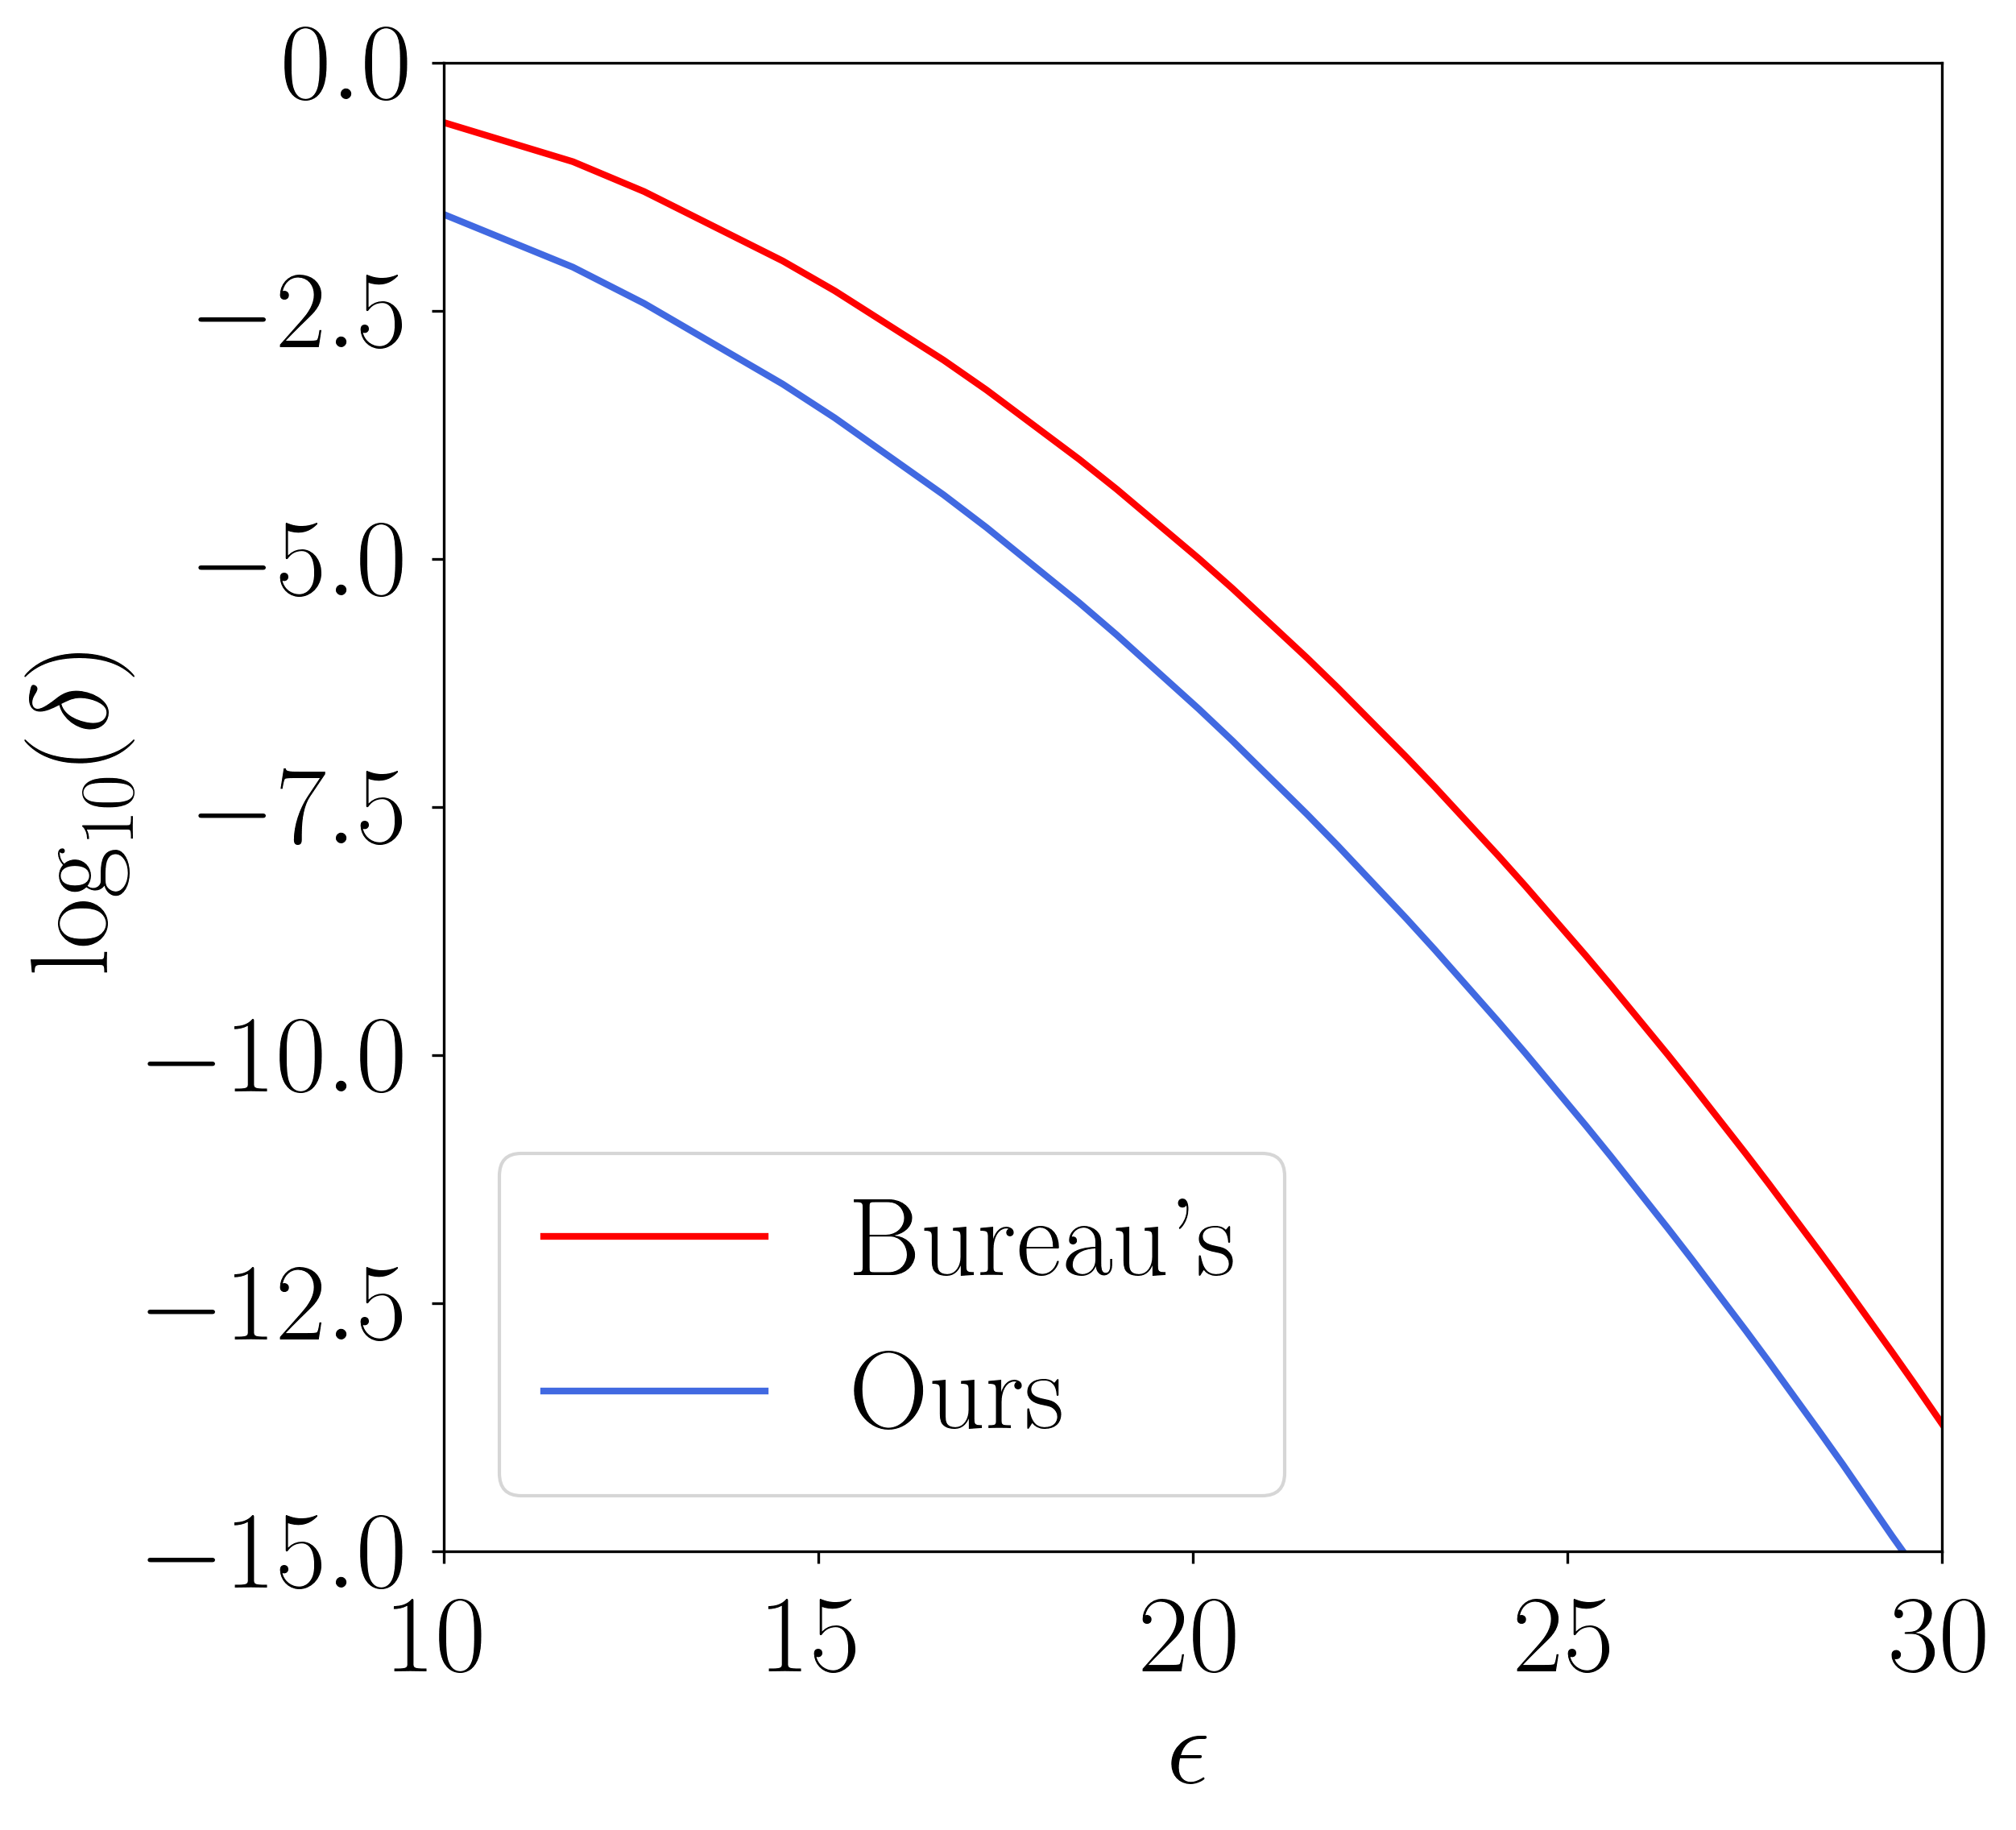

In [67]:
# Extract data
epsilon = eps_delta_curve['epsilon']
delta_zCDP = eps_delta_curve['delta_zcdp']
delta_ours = eps_delta_curve['delta_fdp']

# Convert deltas to log scale
log_delta_ours = [mp.log10(mp.mpf(str(val))) for val in delta_ours]
log_delta_zCDP = [mp.log10(mp.mpf(str(val))) for val in delta_zCDP]


# Plotting
plt.figure()
plt.plot(epsilon, log_delta_zCDP, label="Bureau's", color='red', linewidth=2)
plt.plot(epsilon, log_delta_ours, label='Ours', color='royalblue', linewidth=2)
plt.xlabel(r'$\epsilon$')
plt.ylabel(r'$\log_{10}(\delta)$')
plt.tick_params(axis='x', pad=10)  # Add distance between x-axis tick labels and the axis
plt.tick_params(axis='y', pad=5)  # Add distance between x-axis tick labels and the axis

# plt.title(f"From Path {path_num_1} to {path_num_2}")
plt.legend(loc='lower left')
plt.ylim(-15, 0)
plt.xlim(10, 30)  # Set the x-axis to start at 0

# Save the plot with dynamic filename
file_name = f"results_DHC_v0/eps_delta_curve/figures/epsilon_delta_curve_path_{path_num_1}_to_{path_num_2}.pdf"
plt.savefig(file_name, bbox_inches='tight')

# Display the plot
plt.show()

In [68]:
end_time = time.time()
elapsed_time = (end_time - start_time)/3600
print(f"\n✅ Total runtime: {elapsed_time:.2f} Hours")


✅ Total runtime: 0.51 Hours
